<a href="https://colab.research.google.com/github/elizadunphy/irish-hospital-waiting-list-analysis/blob/main/health_waiting_list_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Irish Hospital Waiting List Analysis**

This project analyses Irish outpatient hospital waiting list data to examine patient waiting times across hospitals.

The dataset includes the number of patients waiting across different time bands:

- 0–6 months
- 6–12 months
- 12–18 months
- 18+ months

The analysis focuses on:

- Waiting list trends over time
- Distribution of waiting lists across hospitals
- Long waiting times of 18+ months
- Differences between Adult and Child patients
- Distribution of patients across waiting time bands

In [ ]:
# Import libraries for data analysis and visualisation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean modern style
sns.set_theme(style="whitegrid")

# Define colour palette (modern + readable)
primary_colour = '#2a9d8f'   # green/teal (main colour)
secondary_colour = '#264653' # dark blue (secondary)
accent_colour = '#e9c46a'    # soft highlight if needed

# Set global font sizes for consistency
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12
})

## **Load Dataset**

The dataset was loaded into the notebook and reviewed to confirm it was imported correctly and ready for analysis.

In [ ]:
# Load dataset and preview first rows

file_name = 'OpenData_OPNational01_2025.csv'

df = pd.read_csv(file_name)
df.head()
df.info()

## **Initial Data Inspection**

The dataset was reviewed to understand its structure, including column names, data types, and overall completeness.

In [ ]:
# Check dataset dimensions
df.shape

In [ ]:
# View column names
df.columns

In [ ]:
# Display dataset structure
df.info()

## **Data Quality Checks**

The dataset was checked for missing values, duplicate records, and consistency across key fields.

In [ ]:
# Check for missing values
df.isnull().sum()

In [ ]:
# Check for duplicate records
df.duplicated().sum()

In [ ]:
# Check patient type values
df['Adult_Child'].unique()

In [ ]:
# Count unique hospitals
df['HospitalName'].nunique()

In [ ]:
# Check date values
df['ArchiveDate'].unique()[:10]

## **Data Cleaning**

The dataset required preparation before analysis. Numeric columns contained formatting (commas) and were stored as text, so these were converted to numeric values. The date column was also converted to a datetime format.

In [ ]:
# Check date values
df['ArchiveDate'].unique()[:10]

In [ ]:
# Convert waiting time columns to numeric

columns_to_clean = [
    '0-6 Months',
    '6-12 Months',
    '12-18 Months',
    '18 Months +',
    'Total'
]

for col in columns_to_clean:
    df[col] = df[col].astype(str)
    df[col] = df[col].str.replace(',', '')
    df[col] = df[col].astype(int)

df[columns_to_clean].dtypes

In [ ]:
# Convert date column to datetime

df['ArchiveDate'] = pd.to_datetime(df['ArchiveDate'])

df['ArchiveDate'].dtype

In [ ]:
df = df.sort_values('ArchiveDate')

## **Exploratory Data Analysis**

The dataset was analysed to identify trends in hospital waiting lists, including changes over time and variation across hospitals.

### ***Waiting List Trends and Distribution***

This section examines overall waiting list trends over time and the distribution of patients across hospitals.

In [ ]:
# Total waiting list over time

monthly_total = df.groupby('ArchiveDate')['Total'].sum()

monthly_total

In [ ]:
# Plot total waiting list over time

plt.figure(figsize=(11,5))

plt.plot(
    monthly_total,
    linewidth=3,
    color=primary_colour
)

plt.fill_between(
    monthly_total.index,
    monthly_total.values,
    color=primary_colour,
    alpha=0.15
)

plt.title('Total Waiting List Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Patients')

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/content/hospital_waiting_list.png', dpi=300, bbox_inches='tight')
plt.show()

**Observation:**

The total waiting list shows an overall upward trend over time, indicating increasing pressure on outpatient services. While there are some short-term fluctuations, the general pattern suggests that demand continues to exceed capacity.

In [ ]:
from google.colab import files
files.download('/content/hospital_waiting_list.png')

#### ***Top 10 Hospitals by Waiting List***

This chart shows the hospitals with the highest total number of patients on waiting lists.

In [132]:
# Total waiting list by hospital

hospital_totals = df.groupby('HospitalName')['Total'].sum()
hospital_totals = hospital_totals.sort_values(ascending=False)

hospital_totals.head(10)

,Total
HospitalName,
Galway University Hospitals,570745
University Hospital Waterford,555204
Beaumont Hospital,531980
Mater Misericordiae University Hospital,484367
Children's Health Ireland,408805
South Infirmary Victoria University Hospital,402325
St. Vincent's University Hospital,397355
University Hospital Limerick,330440
Tallaght University Hospital,309587


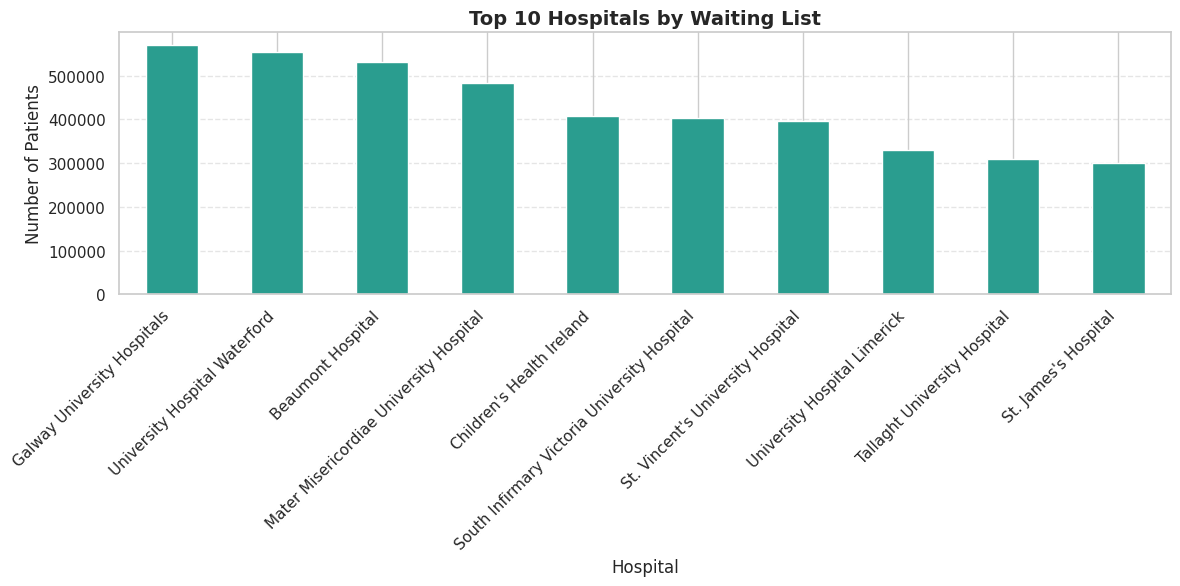

In [139]:
# Plot top 10 hospitals by waiting list

plt.figure(figsize=(12,6))

hospital_totals.head(10).plot(
    kind='bar',
    color=primary_colour
)

plt.title('Top 10 Hospitals by Waiting List', fontsize=14, fontweight='bold')
plt.xlabel('Hospital')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig('/content/top_10_hospitals.png', dpi=300, bbox_inches='tight')

plt.show()

In [140]:
from google.colab import files
files.download('/content/top_10_hospitals.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Observation:**

A small number of hospitals account for a large proportion of total waiting list volumes, with a clear concentration among the highest-volume hospitals.

### ***Long Waiting Times (18+ Months)***

This section examines patients waiting longer than 18 months, which is a key indicator of pressure in the system.

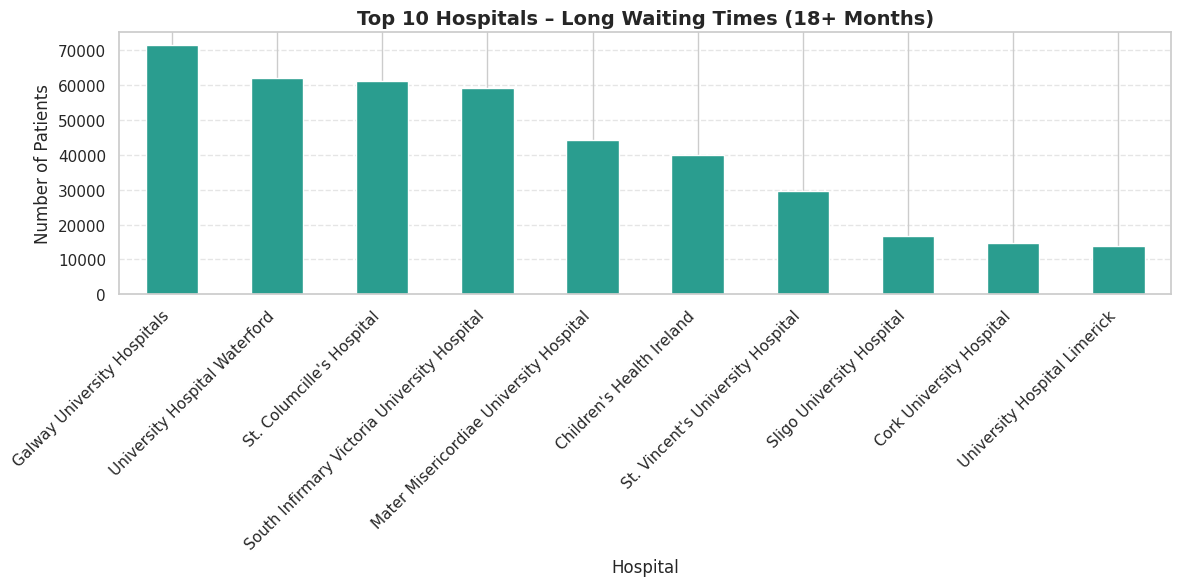

In [134]:
# Plot top 10 hospitals – long waiting times (18+ months)

plt.figure(figsize=(12,6))

long_wait.head(10).plot(
    kind='bar',
    color=bar_colour
)

plt.title('Top 10 Hospitals – Long Waiting Times (18+ Months)', fontsize=14, fontweight='bold')
plt.xlabel('Hospital')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save chart
plt.savefig('/content/long_waits_18_months.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files
files.download('/content/long_waits_18_months.png')

**Observation:**

A small number of hospitals account for a large proportion of long waiting times (18+ months). Galway University Hospitals, University Hospital Waterford, and Beaumont Hospital have the highest numbers of patients waiting over 18 months.

### ***Adult vs Child Waiting Lists***

This section compares total waiting list numbers between Adult and Child patients.

In [135]:
# Total waiting list by patient type

adult_child = df.groupby('Adult_Child')['Total'].sum()

adult_child_df = adult_child.reset_index()
adult_child_df.columns = ['Patient Type', 'No. Waiting']

adult_child_df

,Patient Type,No. Waiting
0,Adult,6348857
1,Child,876629


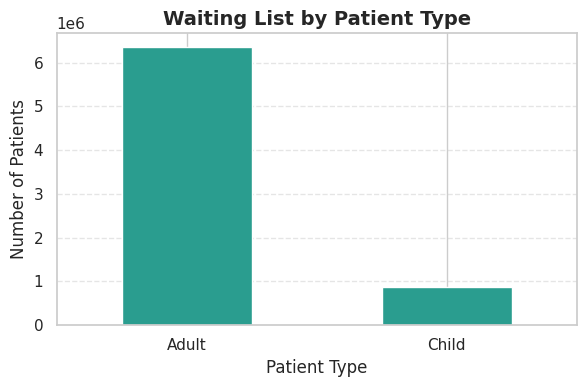

In [136]:
# Plot waiting list by patient type

plt.figure(figsize=(6,4))

adult_child.plot(
    kind='bar',
    color=bar_colour
)

plt.title('Waiting List by Patient Type', fontsize=14, fontweight='bold')
plt.xlabel('Patient Type')
plt.ylabel('Number of Patients')

plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# Save chart
plt.savefig('/content/adult_vs_child.png', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
from google.colab import files
files.download('/content/adult_vs_child.png')

**Observation:**

The waiting list is significantly higher for Adult patients than for Child patients, indicating that demand for adult services accounts for the majority of waiting list pressure.

### ***Waiting Time Distribution***

This section examines how patients are distributed across different waiting time bands.

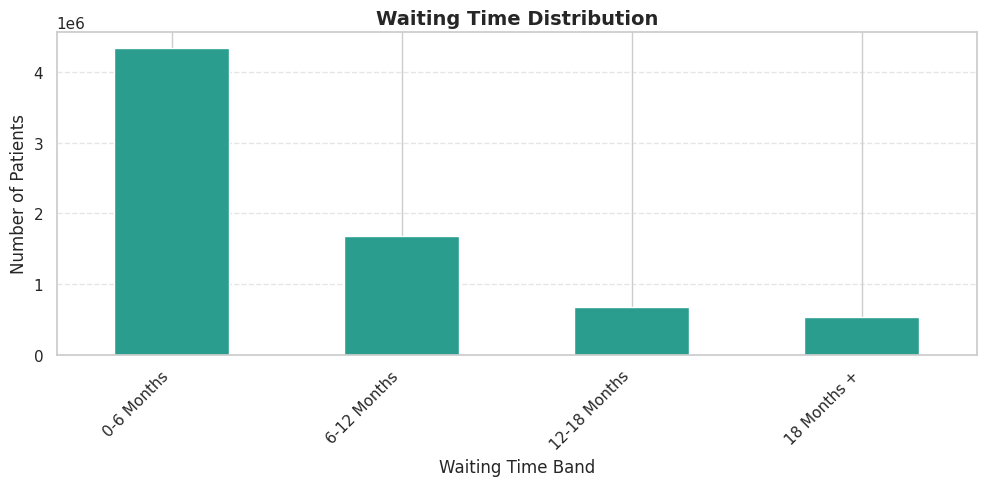

In [137]:
# Waiting time distribution

wait_distribution = df[
    ['0-6 Months', '6-12 Months', '12-18 Months', '18 Months +']
].sum()

plt.figure(figsize=(10,5))

wait_distribution.plot(
    kind='bar',
    color=primary_colour
)

plt.title('Waiting Time Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Waiting Time Band')
plt.ylabel('Number of Patients')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('/content/waiting_time_distribution.png', dpi=300, bbox_inches='tight')

plt.show()

In [138]:
from google.colab import files
files.download('/content/waiting_time_distribution.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Observation:**

The majority of patients are concentrated in the shorter waiting time bands. However, the number of patients waiting 18 months or longer highlights ongoing pressure within the system.

## Conclusion

This analysis examined Irish hospital outpatient waiting list data across hospitals, patient types, and time.

The results show that a small number of hospitals account for a large proportion of total waiting list volumes and long waiting times (18+ months). Adult patients make up the majority of those waiting, indicating higher demand for adult services.

The waiting list is increasing over time, suggesting growing pressure on hospital capacity and the need for continued monitoring and resource planning.